## Polynomial Pipeline

In [1]:
import numpy as np
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [46]:
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,mean_absolute_error,r2_score
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

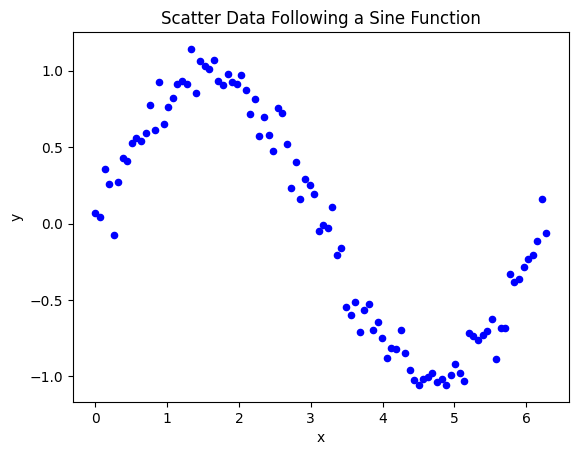

In [41]:


# Generate x values
x = np.linspace(0, 2*np.pi, 100)

# Generate sine-based y values
y = np.sin(x)

# Optional: add noise to make it look like real scatter data
noise = np.random.normal(0, 0.1, len(x))
y_noisy = y + noise

# Plot scatter
plt.scatter(x, y_noisy, color='blue', s=20)
plt.xlabel("x")
plt.ylabel("y")
plt.title("Scatter Data Following a Sine Function")
plt.show()


In [43]:
x

array([0.        , 0.06346652, 0.12693304, 0.19039955, 0.25386607,
       0.31733259, 0.38079911, 0.44426563, 0.50773215, 0.57119866,
       0.63466518, 0.6981317 , 0.76159822, 0.82506474, 0.88853126,
       0.95199777, 1.01546429, 1.07893081, 1.14239733, 1.20586385,
       1.26933037, 1.33279688, 1.3962634 , 1.45972992, 1.52319644,
       1.58666296, 1.65012947, 1.71359599, 1.77706251, 1.84052903,
       1.90399555, 1.96746207, 2.03092858, 2.0943951 , 2.15786162,
       2.22132814, 2.28479466, 2.34826118, 2.41172769, 2.47519421,
       2.53866073, 2.60212725, 2.66559377, 2.72906028, 2.7925268 ,
       2.85599332, 2.91945984, 2.98292636, 3.04639288, 3.10985939,
       3.17332591, 3.23679243, 3.30025895, 3.36372547, 3.42719199,
       3.4906585 , 3.55412502, 3.61759154, 3.68105806, 3.74452458,
       3.8079911 , 3.87145761, 3.93492413, 3.99839065, 4.06185717,
       4.12532369, 4.1887902 , 4.25225672, 4.31572324, 4.37918976,
       4.44265628, 4.5061228 , 4.56958931, 4.63305583, 4.69652

In [44]:
y_noisy

array([ 0.06788349,  0.04055659,  0.35594038,  0.25830533, -0.07401793,
        0.27099245,  0.43101965,  0.41197322,  0.52925565,  0.56182766,
        0.53701   ,  0.59074994,  0.77711403,  0.61340781,  0.92575633,
        0.65178103,  0.76293498,  0.82456379,  0.91521672,  0.93265726,
        0.91479325,  1.14289435,  0.85287257,  1.06108132,  1.03104962,
        1.00920208,  1.07207529,  0.93073208,  0.90953395,  0.97960985,
        0.92941368,  0.91564286,  0.97411265,  0.87450723,  0.71800425,
        0.81603964,  0.57471448,  0.69840908,  0.58198444,  0.47601519,
        0.75652537,  0.72446742,  0.51796501,  0.22958619,  0.40336323,
        0.1606531 ,  0.29300196,  0.24903804,  0.19183074, -0.04644989,
       -0.01088659, -0.02749636,  0.11100551, -0.20827732, -0.16299524,
       -0.54676827, -0.59904879, -0.5151582 , -0.70858432, -0.56373618,
       -0.52784922, -0.69380023, -0.64411883, -0.75052359, -0.87698898,
       -0.81384243, -0.81843913, -0.69892859, -0.84482578, -0.96

In [69]:
### Creating a Pipleline 
def pipeline(degree):
    
    X_train,X_test,y_train,y_test = train_test_split(x,y_noisy,test_size=.2,random_state=42)
    
    poly = PolynomialFeatures(degree=3,include_bias=True)
    model = LinearRegression()
    
    
    pipe = Pipeline([
        ('poly_features',poly),
        ('linear_model',model)
    ])
    
    pipe.fit(X_train.reshape(-1,1),y_train)
    
    y_pred = pipe.predict(np.array(X_test.reshape(-1,1)))
    
    sns.scatterplot(x=X_train,y=y_train)
    sns.regplot(x=X_train,y=y_train)
    plt.show()
    
    
    
    
    
    
    

In [105]:
def pipeline(degree):
    
    X_train, X_test, y_train, y_test = train_test_split(
        x, y_noisy, test_size=0.2, random_state=42
    )
    
    poly = PolynomialFeatures(degree=degree, include_bias=True)
    model = LinearRegression()
    
    pipe = Pipeline([
        ('poly_features', poly),
        ('linear_model', model)
    ])
    
    pipe.fit(X_train.reshape(-1,1), y_train)
    
    # Create smooth X range
    X_range = np.linspace(x.min(), x.max(), 200).reshape(-1,1)
    y_range_pred = pipe.predict(X_range)
    
    # Plot
    plt.scatter(X_train, y_train, label="Train Data")
    # plt.scatter(X_test, y_test, color='green', label="Test Data")
    plt.plot(X_range, y_range_pred, color='red', linewidth=2, label="Model")
    
    plt.title(f"Polynomial Degree = {degree}")
    plt.legend()
    plt.show()


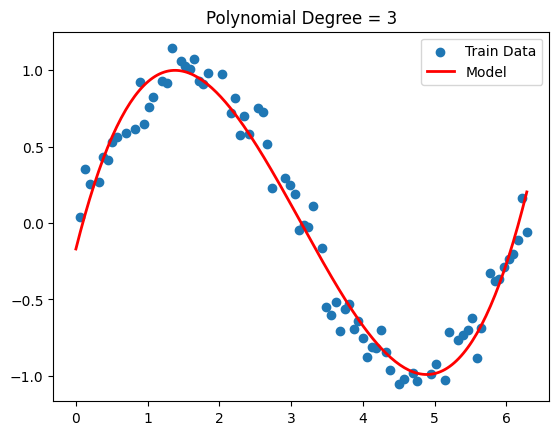

In [106]:
pipeline(3)